In [1]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [3]:
import xarray as xr

with xr.open_dataset('/home/usman/Music/GeeMap/Results/15_GCM_projections.nc') as ds:
    ds_merged = ds


In [4]:
ds_merged

<xarray.Dataset> Size: 14MB
Dimensions:                       (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15,
                                   month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B ...
    hydro_month                   (time) int64 696B ...
    calendar_year                 (time) int64 696B ...
    calendar_month                (time) int64 696B ...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B ...
  * GCM                           (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'u...
  * SCENARIO                      (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Data variables: (12/24)
    volume                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bsl                    (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bwl                    (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    area                          (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    length                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    calving                       (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    ...                            ...
    liq_prcp_on_glacier_monthly   (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    snowfall_off_glacier_monthly  (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    snowfall_on_glacier_monthly   (SCENARIO, GCM, time, month_2d, rgi_id) float64 2MB ...
    water_level                   (SCENARIO, GCM, rgi_id) float64 2kB ...
    glen_a                        (SCENARIO, GCM, rgi_id) float64 2kB ...
    fs                            (SCENARIO, GCM, rgi_id) float64 2kB ...
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-09 06:36:16

In [5]:
# Replace 'runoff_variable' with the appropriate variable name for runoff in your dataset
runoff_variable = 'melt_off_glacier'  # Update this if necessary

# Sum over all glaciers (rgi_id) to get total runoff
ds_total_runoff = ds_merged[runoff_variable].sum(
    dim='rgi_id',  # Sum over all glacier IDs
    skipna=True,   # Ignore NaN values
    min_count=len(ds_merged.rgi_id),  # Ensure all glacier data is required
    keep_attrs=True  # Keep metadata
)

# Print a summary of the total runoff data
print(ds_total_runoff)


<xarray.DataArray 'melt_off_glacier' (SCENARIO: 3, GCM: 5, time: 87)> Size: 10kB
array([[[4.16038845e+08, 3.33735947e+08, 1.12230845e+09, ...,
         2.39404167e+10, 3.04924618e+10,            nan],
        [1.39645670e+09, 8.63006543e+08, 7.24354474e+08, ...,
         2.25483983e+10, 2.52337470e+10,            nan],
        [2.97376978e+08, 1.17046077e+09, 7.50864316e+08, ...,
         1.76873308e+10, 2.21739570e+10,            nan],
        [3.28964905e+08, 6.77488170e+08, 6.14432765e+08, ...,
         1.66334766e+10, 1.57486255e+10,            nan],
        [1.61738007e+08, 5.50057885e+08, 2.56799661e+08, ...,
         3.87974064e+10, 1.46617705e+10,            nan]],

       [[5.11269100e+08, 8.59289651e+08, 7.44910482e+08, ...,
         4.36988100e+10, 4.57574020e+10,            nan],
        [3.34645694e+08, 2.77755304e+08, 3.48471734e+08, ...,
         5.24085958e+10, 1.17898018e+10,            nan],
        [3.44737320e+08, 5.56583394e+08, 5.89142979e+08, ...,
         5.8396

In [9]:
ds_total_runoff_m3 = ds_total_runoff / 1e3  # Convert kg to m³
print(ds_total_runoff_m3)


<xarray.DataArray 'melt_off_glacier' (SCENARIO: 3, GCM: 5, time: 87)> Size: 10kB
array([[[4.16038845e+02, 3.33735947e+02, 1.12230845e+03, ...,
         2.39404167e+04, 3.04924618e+04,            nan],
        [1.39645670e+03, 8.63006543e+02, 7.24354474e+02, ...,
         2.25483983e+04, 2.52337470e+04,            nan],
        [2.97376978e+02, 1.17046077e+03, 7.50864316e+02, ...,
         1.76873308e+04, 2.21739570e+04,            nan],
        [3.28964905e+02, 6.77488170e+02, 6.14432765e+02, ...,
         1.66334766e+04, 1.57486255e+04,            nan],
        [1.61738007e+02, 5.50057885e+02, 2.56799661e+02, ...,
         3.87974064e+04, 1.46617705e+04,            nan]],

       [[5.11269100e+02, 8.59289651e+02, 7.44910482e+02, ...,
         4.36988100e+04, 4.57574020e+04,            nan],
        [3.34645694e+02, 2.77755304e+02, 3.48471734e+02, ...,
         5.24085958e+04, 1.17898018e+04,            nan],
        [3.44737320e+02, 5.56583394e+02, 5.89142979e+02, ...,
         5.8396

In [7]:
ds_total_runoff_median = ds_total_runoff.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_runoff_median

<xarray.DataArray 'melt_off_glacier' (SCENARIO: 3, time: 87)> Size: 2kB
array([[  328964.90490383,   677488.16953968,   724354.47441377,
          632509.9234365 ,   673583.66870349,   998507.89040606,
          827417.32400099,  1033153.23793973,  1181782.16661783,
         1507877.831617  ,  1476972.76391419,  1271655.87138199,
         1196913.93814667,  1644728.36916371,  1610335.61840206,
         1545177.28642318,  2100603.9549738 ,  1977153.96512232,
         2658466.289432  ,  3069714.21355458,  2785251.63165247,
         3618949.9799671 ,  2324367.5759397 ,  4069798.17330163,
         3351225.37487469,  4296674.45458297,  5587212.49061567,
         4944153.79802084,  6025649.60093112,  5800603.33258571,
         5094270.79525361,  4068104.99610426,  5349626.02892328,
         7331640.33939483,  5081847.89806704,  5819202.34828449,
         7354969.40929301,  5223923.09735891,  7203461.83498015,
         8857108.61601192, 10288977.30458906,  8120004.83938485,
         6167403.58405918,  7860884.01322004, 10157535.1579651 ,
         6467934.70376277, 11913804.44216029,  7750488.10894072,
        11491267.45447809, 12552874.62598968, 11382411.72298229,
        13510608.80664966, 15006884.35505879, 15074490.2755996 ,
        14316916.96735711, 14584274.93191002,  8509062.69743367,
        12609845.55394602, 16338756.85797572, 15847190.94866216,
...
         3991213.16463653,  6528422.50281843,  6051577.02453871,
         6362854.02428034,  5782858.64507341,  8218985.61419785,
         6222883.35526211,  8126734.40876339, 10477589.5991186 ,
         9317829.85278461,  6175542.59463267, 13059662.57709217,
         8171966.35030599,  9815645.84445827, 11256032.73081293,
        12556362.90986473,  8876066.70938198, 10640338.62599285,
        12584450.22433218, 16145452.64488732, 13934806.96058688,
        16066920.35130659, 15845731.44146961, 22462228.44612578,
        22648520.03888518, 19053445.15443538, 19628238.23518929,
        25706947.8559854 , 25657891.16501726, 28261801.51232732,
        27980465.1143376 , 32309281.3043024 , 21960723.93367711,
        22227560.11086529, 22873289.47683971, 24734469.50190365,
        25943173.44997109, 24781848.80427395, 28592107.12758331,
        25257067.4152998 , 47307609.13125537, 32131881.41109001,
        43011705.66786891, 29843155.3264178 , 38381229.68412875,
        32854717.59876755, 38570524.88169644, 35614587.4559109 ,
        48207317.91422066, 36926046.62750982, 57676150.72014338,
        43535518.00081787, 51589049.64794222, 39183932.55129272,
        54717071.58222844, 53529560.49091598, 65770702.23139649,
        49261004.01815676, 65145634.44417887,               nan]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_runoff = ds_total_runoff.to_dataframe('runoff_m3').reset_index()

# Filter the time range from 2015 to 2023
pd_total_runoff_filtered = pd_total_runoff[(pd_total_runoff['time'] >= 2015) & (pd_total_runoff['time'] <= 2023)]

# Convert runoff from m³ to km³ for better readability
pd_total_runoff_filtered['runoff_km3'] = pd_total_runoff_filtered['runoff_m3'] / 1e9  # Convert to km³

# Plot with Seaborn
sns.lineplot(x='time', y='runoff_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_runoff_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Runoff (km$^3$)')
plt.title('Glacier Runoff Projections (2015-2023)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2015, 2023)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Runoff/Glacier_Runoff_2015_2023.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


In [8]:
import matplotlib.pyplot as plt

In [6]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)

In [13]:
import pandas as pd

# Convert xarray datasets into pandas DataFrames
df_median = ds_total_volume_median.to_dataframe('median_volume_m3').reset_index()
df_mean = ds_total_volume_mean.to_dataframe('mean_volume_m3').reset_index()
df_min = ds_total_volume_min.to_dataframe('min_volume_m3').reset_index()
df_max = ds_total_volume_max.to_dataframe('max_volume_m3').reset_index()
df_p25 = ds_total_volume_p25.to_dataframe('p25_volume_m3').reset_index()
df_p75 = ds_total_volume_p75.to_dataframe('p75_volume_m3').reset_index()
df_std = ds_total_volume_std.to_dataframe('std_volume_m3').reset_index()

# Merge DataFrames on correct keys, avoiding duplicate columns
merge_keys = ['time', 'SCENARIO']  # Adjust keys if needed

# Drop duplicate or unnecessary columns before merging
df_median = df_median.loc[:, ~df_median.columns.duplicated()]
df_mean = df_mean.loc[:, ~df_mean.columns.duplicated()]
df_min = df_min.loc[:, ~df_min.columns.duplicated()]
df_max = df_max.loc[:, ~df_max.columns.duplicated()]
df_p25 = df_p25.loc[:, ~df_p25.columns.duplicated()]
df_p75 = df_p75.loc[:, ~df_p75.columns.duplicated()]
df_std = df_std.loc[:, ~df_std.columns.duplicated()]

# Start merging
df_combined = pd.merge(df_median, df_mean, on=merge_keys, how='outer', suffixes=('', '_mean'))
df_combined = pd.merge(df_combined, df_min, on=merge_keys, how='outer', suffixes=('', '_min'))
df_combined = pd.merge(df_combined, df_max, on=merge_keys, how='outer', suffixes=('', '_max'))
df_combined = pd.merge(df_combined, df_p25, on=merge_keys, how='outer', suffixes=('', '_p25'))
df_combined = pd.merge(df_combined, df_p75, on=merge_keys, how='outer', suffixes=('', '_p75'))
df_combined = pd.merge(df_combined, df_std, on=merge_keys, how='outer', suffixes=('', '_std'))

# Save the combined DataFrame to an Excel file
excel_output_path = '/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_data_2020_2050.xlsx'
df_combined.to_excel(excel_output_path, index=False)

# Print Excel save confirmation
print(f"Final data saved to: {excel_output_path}")


Final data saved to: /home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_data_2020_2050.xlsx


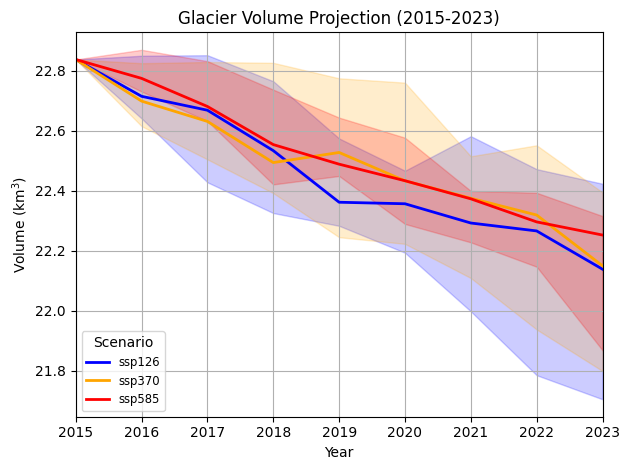

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2023.png


In [35]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_runoff.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2015) & (pd_total_volume['time'] <= 2023)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2015-2023)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2015, 2023)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2023.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


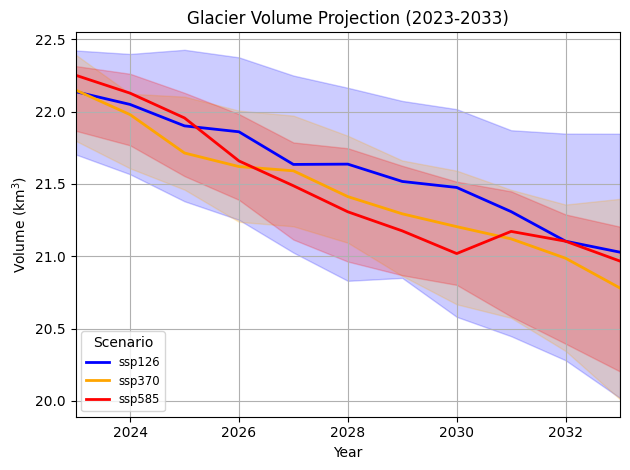

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2023_2033.png


In [36]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2023) & (pd_total_volume['time'] <= 2033)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2023-2033)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2023, 2033)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2023_2033.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


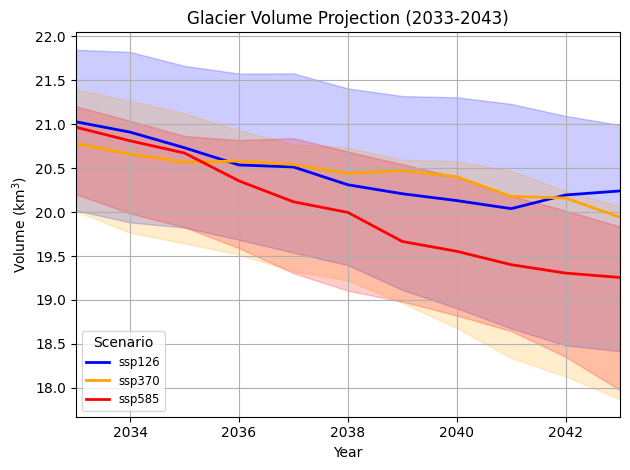

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2033_2043.png


In [37]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2033) & (pd_total_volume['time'] <= 2043)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2033-2043)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2033, 2043)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2033_2043.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


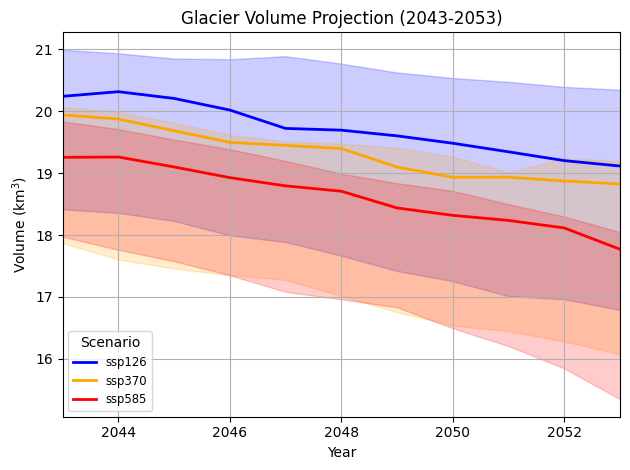

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2043_2053.png


In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2043) & (pd_total_volume['time'] <= 2053)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2043-2053)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2043, 2053)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2043_2053.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


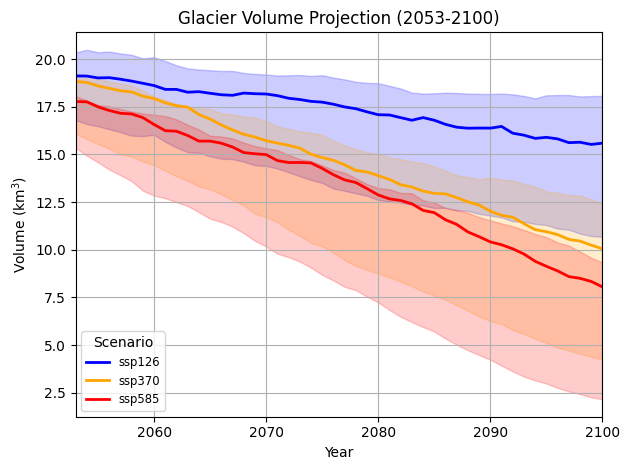

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2053_2100.png


In [39]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2053) & (pd_total_volume['time'] <= 2100)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2053-2100)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2053, 2100)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2053_2100.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


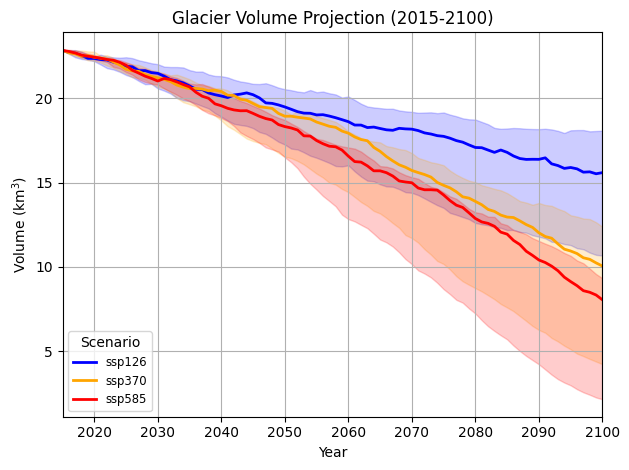

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2100.png


In [41]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2015) & (pd_total_volume['time'] <= 2100)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2015-2100)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2015, 2100)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2100.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")
